# Tropical Pacific PCA and an independent Niño 3.4 index

Two independent analyses of ERA5 sea surface temperature (SST):

1. **PCA over the tropical Pacific (30°S–30°N, 120°E–290°E):** identify spatial patterns and their temporal evolution after removing the seasonal cycle and linear trends.
2. **A geographical average over Niño 3.4 (5°S–5°N, 190°E–240°E):** calculate temperature anomalies and a three-month mean, without PCA or trend removal.
3. **Only after both calculations**, compare tropical PC1 with the ERA5 ONI-like index.

All PCA fits use the same tropical domain. Niño 3.4 is outlined on the PCA maps only as a geographical reference; it does not define the PCA input. The index section colors SST only inside that small box to show its independent input.

Uses preprocessed ERA5 monthly SST (1979–2025, 2° grid) from the GeoOcean THREDDS server, BlueMath PCA, Xarray, NumPy, pandas, Matplotlib and Cartopy. The index is a teaching estimate with a fixed 1991–2020 baseline, not the published CPC ONI.

In [1]:
from pathlib import Path
import logging

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Rectangle
from bluemath_tk.datamining.pca import PCA

logging.getLogger("PCA").setLevel(logging.ERROR)

## 1. Download and load SST

The dataset is a preprocessed ERA5 product served from the GeoOcean THREDDS server. It was built from daily 0.25° SST by selecting complete years **1979–2025**, averaging **8 × 8 spatial blocks** (0.25° → 2°), and then averaging days within each calendar month. Incomplete edge blocks were trimmed; this gives **60 × 95** block centers, not a selection of every eighth point. Values are stored in kelvin.

The **564 × 60 × 95** monthly array is about **13 MB** in float32. It is downloaded once into `toolkit/data/outputs/`; later runs reuse the local copy. Missing SST over land stays masked; coastal blocks average their available ocean values.

In [2]:
# Works when launched from the repository root or toolkit/datamining.
repo_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "toolkit" / "data").is_dir()
)
data_path = repo_root / "toolkit" / "data" / "outputs"
data_path.mkdir(parents=True, exist_ok=True)
start_year, end_year = 1979, 2025
resolution = 2  # degrees
baseline = slice("1991-01-01", "2020-12-31")
n_modes = 4

# Download the monthly SST dataset once (skipped if it already exists).
# --no-check-certificate: the GeoOcean server certificate expired on 2026-10-01.
data_url = "https://geoocean.unican.es/thredds/fileServer/rawData/GEOOCEAN/BlueMath_Course_Corvallis/era5_pacific_sst_1979-2025_2deg_blockmean_monthly_K.nc"
sst_file = data_path / Path(data_url).name
!wget -nc -q --show-progress --no-check-certificate -P "{data_path}" "{data_url}"

In [3]:
with xr.open_dataset(sst_file) as source:
    sst = (source.sst.load() - 273.15).transpose("time", "latitude", "longitude")
sst.attrs = {"long_name": "Monthly sea surface temperature", "units": "degC"}
print(f"{sst.sizes}; {sst.nbytes / 1e6:.1f} MB in memory")
sst

Frozen({'time': 564, 'latitude': 60, 'longitude': 95}); 12.9 MB in memory


<xarray.DataArray 'sst' (time: 564, latitude: 60, longitude: 95)> Size: 13MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ..., -1.6499939 ,
                 nan,         nan],
        [ 0.1000061 ,         nan,         nan, ..., -1.6499939 ,
                 nan,         nan],
        ...,
        [ 3.0959167 ,  2.7241516 ,  2.9777832 , ...,  8.237488  ,
          8.793945  ,  8.502136  ],
        [ 2.2673035 ,  2.2815247 ,  2.5451355 , ...,  7.329651  ,
          7.445282  ,  7.413513  ],
        [ 1.6790771 ,  1.7531738 ,  1.9093628 , ...,  6.473755  ,
          6.517334  ,  6.344879  ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ..., -1.6499939 ,
                 nan,         nan],
        [ 0.1000061 ,         nan,         nan, ..., -1.6499939 ,
                 nan,         nan],
...
        [ 2.0115356 ,  1.7163086 ,  2.1705017 , ...,  6.2922974 ,
          6.7137756 ,  6.5209045 ],
        [ 0.68170166,  0.60253906,  0.98828125, ...,  5.6045227 ,
          5.707611  ,  5.5519714 ],
        [-0.26055908,  0.2338562 ,  0.30215454, ...,  4.9408264 ,
          5.072357  ,  4.8390503 ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ..., -0.5723877 ,
                 nan,         nan],
        [ 0.1000061 ,         nan,         nan, ..., -0.5723877 ,
                 nan,         nan],
        ...,
        [ 3.4118652 ,  3.488617  ,  3.827362  , ...,  6.8952026 ,
          7.2470703 ,  7.2251587 ],
        [ 2.5719604 ,  2.742279  ,  2.869934  , ...,  6.22287   ,
          6.346039  ,  6.302826  ],
        [ 1.6889038 ,  1.7765198 ,  2.0440063 , ...,  5.3299255 ,
          5.429718  ,  5.5429688 ]]], shape=(564, 60, 95), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2025-12-01
  * latitude   (latitude) float64 480B 59.12 57.12 55.12 ... -56.88 -58.88
  * longitude  (longitude) float64 760B 100.9 102.9 104.9 ... 284.9 286.9 288.9
Attributes:
    long_name:  Monthly sea surface temperature
    units:      degC

### One domain for all PCA fits

Select the tropical Pacific before any PCA. The outlined Niño 3.4 box is a reference for the separate index analysis later.


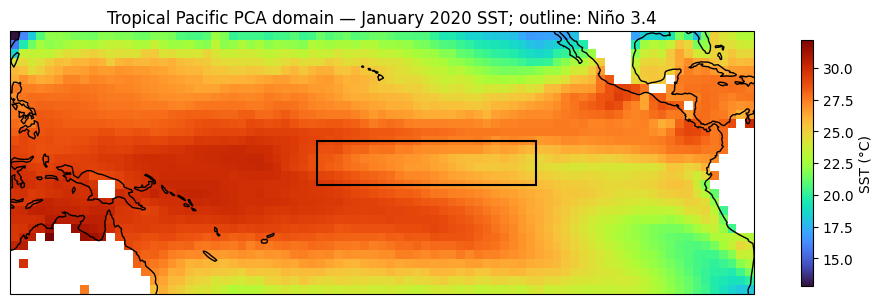

In [4]:
def select_box(field, south, north, west, east):
    # Boolean selection works with either ascending or descending latitude.
    return field.where(
        (field.latitude >= south) & (field.latitude <= north)
        & (field.longitude >= west) & (field.longitude <= east), drop=True,
    )


def area_mean(field):
    return field.weighted(np.cos(np.deg2rad(field.latitude))).mean(
        ("latitude", "longitude"), skipna=True,
    )



# Use this same domain for every PCA below.
sst = select_box(sst, -30, 30, 120, 290)
projection = ccrs.PlateCarree(central_longitude=180)

def draw_nino34(ax):
    ax.add_patch(Rectangle((190, -5), 50, 10, fill=False, edgecolor="black",
                           linewidth=1.5, transform=ccrs.PlateCarree()))

fig, ax = plt.subplots(figsize=(12, 4), subplot_kw={"projection": projection})
sst.sel(time="2020-01-01").plot.pcolormesh(
    ax=ax, transform=ccrs.PlateCarree(), cmap="turbo",
    cbar_kwargs={"label": "SST (°C)", "shrink": 0.8},
)
ax.coastlines()
draw_nino34(ax)
ax.set_title("Tropical Pacific PCA domain — January 2020 SST; outline: Niño 3.4");


## 2. Analysis A: PCA setup

Every PCA fit below uses the same helper and fits just **four modes**. Every month is a row and each retained ocean cell is a feature. Cells with missing values at any month, or no temporal variance, are excluded rather than filled with artificial temperatures.

Multiply SST by $\sqrt{\cos(\varphi)}$ before fitting to account for grid-cell area. We use `scale_data=False`: standardizing each cell would cancel these weights and change a covariance PCA into a correlation PCA. BlueMath still centers each feature.

For interpretation, the helper converts weighted EOFs to temperature patterns associated with **one standard deviation of a PC**. The maps are in °C; the displayed PCs are dimensionless. Their product recovers the contribution of a mode to the centered SST field.

In [5]:
def fit_sst_pca(field, n_components=4):
    field = field.transpose("time", "latitude", "longitude")
    ocean = np.isfinite(field).all("time") & (field.std("time") > 0)
    if int(ocean.sum()) < n_components:
        raise ValueError("Not enough complete ocean cells for PCA.")
    weights = np.sqrt(np.cos(np.deg2rad(field.latitude)))
    weighted = (field.where(ocean) * weights).rename("sst")
    model = PCA(n_components=n_components)
    # A fixed seed makes a randomized solver reproducible if selected internally.
    model.pca.set_params(random_state=0)
    scores = model.fit_transform(
        data=weighted.to_dataset(),
        vars_to_stack=["sst"],
        coords_to_stack=["latitude", "longitude"],
        pca_dim_for_rows="time",
        scale_data=False,
    ).PCs
    score_std = scores.std("time", ddof=1)
    pcs = scores / score_std
    patterns = (model.eofs.sst / weights * score_std).where(ocean)
    patterns.attrs = {"units": "degC", "long_name": "SST pattern per PC standard deviation"}
    print(f"PCA: {field.sizes['time']} months × {int(ocean.sum())} ocean cells")
    return model, pcs, patterns


from matplotlib.colors import LinearSegmentedColormap

# A diverging scale preserves the sign of EOF patterns.
pca_cmap = LinearSegmentedColormap.from_list("pca", ["#DF826B", "#FFFFFF", "#29ABAF"])

def plot_modes(model, pcs, patterns, title, count=3):
    fig, axes = plt.subplots(
        1, count, figsize=(5 * count, 3.5),
        subplot_kw={"projection": projection}, layout="constrained",
    )
    for i, ax in enumerate(np.atleast_1d(axes)):
        patterns.isel(n_component=i).plot.pcolormesh(
            ax=ax, transform=ccrs.PlateCarree(), cmap=pca_cmap, center=0,
            cbar_kwargs={"label": "°C per PC std", "shrink": 0.7},
        )
        ax.coastlines()
        draw_nino34(ax)
        ax.set_title(f"EOF {i + 1} ({model.explained_variance_ratio[i]:.1%})")
    fig.suptitle(title)
    fig, axes = plt.subplots(count, 1, figsize=(13, 2 * count), sharex=True, layout="constrained")
    for i, ax in enumerate(np.atleast_1d(axes)):
        pcs.isel(n_component=i).plot(ax=ax, linewidth=0.8, color="#29ABAF")
        ax.set(title="", ylabel=f"PC{i + 1} (std)")
        ax.axhline(0, color="grey", linewidth=0.5)
    return fig

## 3. Analysis A: tropical anomaly PCA

First subtract each calendar month's **1991–2020 climatology**. Keep these original anomalies for Niño 3.4 and the ONI-like index.

For PCA only, remove a **linear trend at every grid point** over 1979–2025. The reference subtracts a global-mean anomaly; our file covers only the Pacific, so we cannot reproduce that global correction. A local linear detrend is an explicit alternative, not an equivalent operation. It may also remove some low-frequency variability.

The anomaly PCA and the index therefore have different preprocessing. Their agreement is something to measure, not an identity.
The first EOF is a candidate ENSO pattern. Its sign is arbitrary; we will orient it consistently with Niño 3.4 only in the final comparison.

PCA: 564 months × 2384 ocean cells


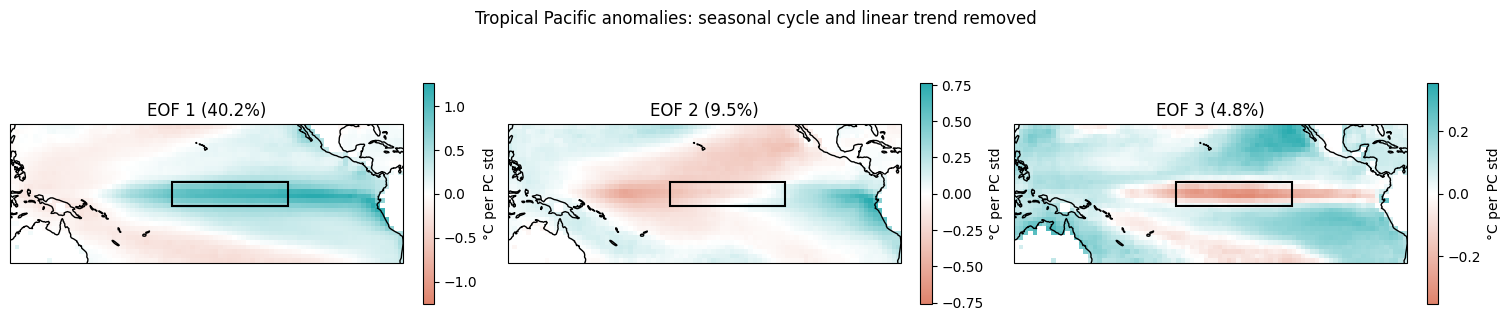

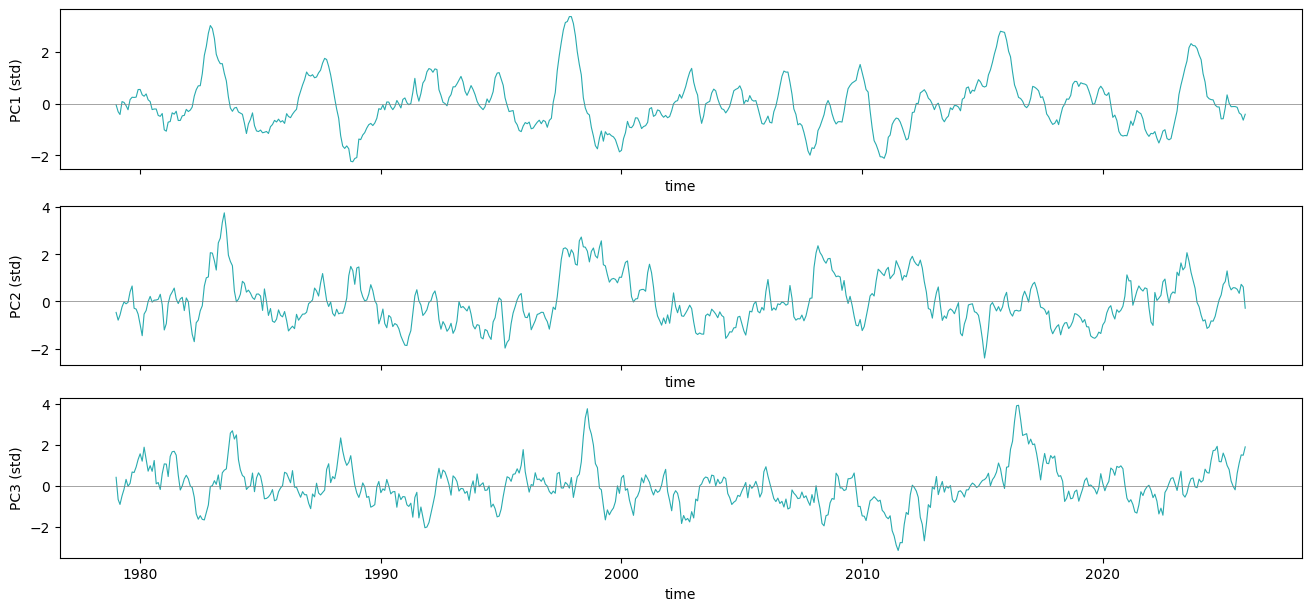

In [6]:
reference = sst.sel(time=baseline)
if reference.sizes["time"] != 30 * 12:
    raise ValueError("The 1991–2020 monthly baseline must contain 360 months.")
climatology = reference.groupby("time.month").mean("time")
ssta = (sst.groupby("time.month") - climatology).drop_vars("month")
ssta.attrs = {"long_name": "SST anomaly relative to 1991–2020", "units": "degC"}

# Centered month coordinate: slope has units °C/month.
t = xr.DataArray(np.arange(ssta.sizes["time"], dtype=float),
                 dims="time", coords={"time": ssta.time})
t = t - t.mean("time")
complete_ocean = np.isfinite(ssta).all("time")
centered = ssta.where(complete_ocean) - ssta.where(complete_ocean).mean("time")
slope = (centered * t).sum("time") / (t**2).sum("time")
ssta_detrended = (centered - slope * t).where(complete_ocean)
ssta_detrended.attrs = {"long_name": "Linearly detrended SST anomaly", "units": "degC"}

enso_model, enso_pcs, enso_patterns = fit_sst_pca(ssta_detrended, n_modes)
plot_modes(enso_model, enso_pcs, enso_patterns,
           "Tropical Pacific anomalies: seasonal cycle and linear trend removed");


## 4. Analysis B: independent Niño 3.4 / ONI-like calculation

Average the **undetrended** monthly SST anomalies over Niño 3.4 using area weights, then apply a **centered three-month running mean**. January labels DJF, February labels JFM, and so on. The first and last months remain missing because a full three-month window is required.

This is an **ERA5 ONI-like index with a fixed 1991–2020 baseline**. The [CPC ONI](https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso/oni/v6/) uses ERSST and centered 30-year reference periods updated every five years. Dataset, grid and baseline differences prevent this calculation from reproducing the published ONI exactly. The ±0.5°C lines are visual guides; we do not classify events from isolated threshold crossings.
The next figure shows the calculation from SST to anomalies to a regional mean. Only cells inside Niño 3.4 are colored; this analysis does not use the PCA results.


In [7]:
nino34_box = select_box(ssta, -5, 5, 190, 240)
# Keep a fixed spatial mask so varying coverage cannot change the averaging area.
nino34_box = nino34_box.where(np.isfinite(nino34_box).all("time"))
if not bool(nino34_box.notnull().any()):
    raise ValueError("No complete ocean cells in Niño 3.4.")
nino34 = area_mean(nino34_box).rename("nino34_era5")
nino34.attrs = {"long_name": "ERA5 Niño 3.4 monthly SST anomaly", "units": "degC", "baseline": "1991–2020"}
oni_era5 = nino34.rolling(time=3, center=True, min_periods=3).mean().rename("oni_like_era5")
oni_era5.attrs = {"long_name": "ERA5 ONI-like index (not CPC ONI)", "units": "degC",
                  "baseline": "1991–2020", "smoothing": "Centered 3-month mean"}



January 2020 Niño 3.4 anomaly: 0.47 °C
December–January–February mean: 0.39 °C


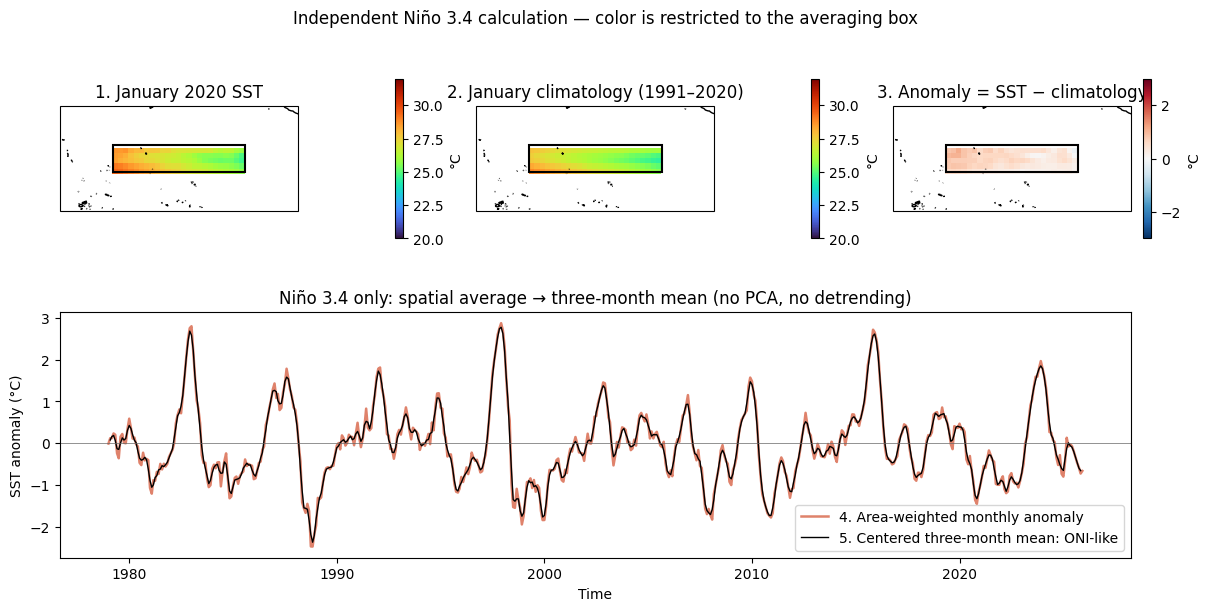

In [8]:
# Demonstrate the index calculation for January 2020.
example_date = "2020-01-01"
sst_box = select_box(sst, -5, 5, 190, 240).where(nino34_box.notnull().all("time"))
clim_box = select_box(climatology, -5, 5, 190, 240).where(nino34_box.notnull().all("time"))
fig = plt.figure(figsize=(12, 6), layout="constrained")
gs = fig.add_gridspec(2, 3)
fields = [sst_box.sel(time=example_date), clim_box.sel(month=1),
          nino34_box.sel(time=example_date)]
titles = ["1. January 2020 SST", "2. January climatology (1991–2020)",
          "3. Anomaly = SST − climatology"]
for i, (field, title) in enumerate(zip(fields, titles)):
    ax = fig.add_subplot(gs[0, i], projection=projection)
    # Context stays uncolored: only Niño 3.4 contributes to the index.
    ax.set_extent([170, 260, -20, 20], crs=ccrs.PlateCarree())
    options = {"cmap": "turbo", "vmin": 20, "vmax": 32} if i < 2 else {
        "cmap": "RdBu_r", "vmin": -3, "vmax": 3}
    field.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(),
                         cbar_kwargs={"label": "°C", "shrink": 0.65}, **options)
    ax.coastlines()
    draw_nino34(ax)
    ax.set_title(title)
ax = fig.add_subplot(gs[1, :])
nino34.plot(ax=ax, color="#DF826B", linewidth=1.8, label="4. Area-weighted monthly anomaly")
oni_era5.plot(ax=ax, color="black", linewidth=1, label="5. Centered three-month mean: ONI-like")
ax.axhline(0, color="0.4", linewidth=0.5)
ax.set(title="Niño 3.4 only: spatial average → three-month mean (no PCA, no detrending)",
       ylabel="SST anomaly (°C)", xlabel="Time")
ax.legend()
fig.suptitle("Independent Niño 3.4 calculation — color is restricted to the averaging box")
print(f"January 2020 Niño 3.4 anomaly: {float(nino34.sel(time=example_date)):.2f} °C")
print(f"December–January–February mean: {float(oni_era5.sel(time=example_date)):.2f} °C")


## 5. Compare the two independently calculated indices

Only now bring the results together. Smooth tropical PC1 over three months and orient its arbitrary sign for positive correlation with the ONI-like series, changing the EOF sign consistently. This changes neither the PCA fit nor the independently calculated index. PC1 is dimensionless; the Niño 3.4 index is in °C.


In [9]:
pc1 = enso_pcs.isel(n_component=0, drop=True)
pc1_smoothed = pc1.rolling(time=3, center=True, min_periods=3).mean()
raw_correlation = float(xr.corr(pc1_smoothed, oni_era5, dim="time"))
sign = -1.0 if raw_correlation < 0 else 1.0
# Orient both the pattern and score; all other modes retain their fitted signs.
orientation = xr.ones_like(enso_pcs.isel(time=0, drop=True))
orientation[0] = sign
enso_pcs = enso_pcs * orientation
enso_patterns = enso_patterns * orientation
enso_pc1 = (pc1_smoothed * sign).rename("enso_pc1_3month")
enso_pc1.attrs = {"long_name": "Tropical Pacific PC1, centered 3-month mean",
                   "units": "1", "normalization": "Monthly PC divided by its sample standard deviation before smoothing"}


(np.float64(3287.0), np.float64(20423.0))

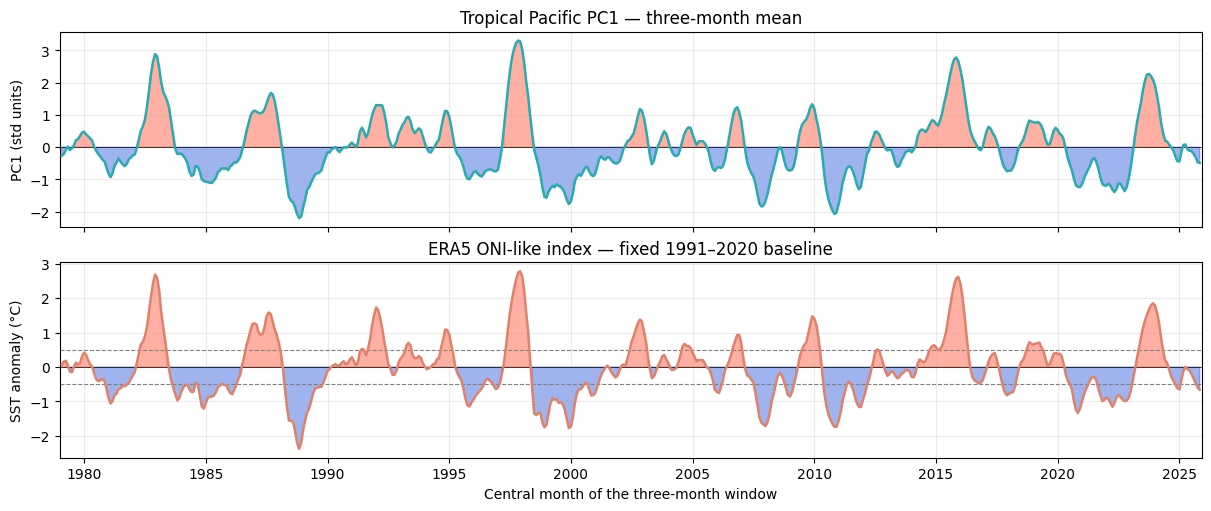

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, layout="constrained")
for ax, series, title, label, color in [
    (axes[0], enso_pc1, "Tropical Pacific PC1 — three-month mean", "PC1 (std units)", "#29ABAF"),
    (axes[1], oni_era5, "ERA5 ONI-like index — fixed 1991–2020 baseline", "SST anomaly (°C)", "#DF826B"),
]:
    ax.plot(series.time, series, color=color, linewidth=1.8, zorder=3)
    ax.fill_between(series.time.values, 0, series.values, where=series.values >= 0, color="tomato", alpha = .5)
    ax.fill_between(series.time.values, 0, series.values, where=series.values < 0, color="royalblue", alpha = .5)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set(title=title, ylabel=label)
    ax.grid(alpha=0.25)
for threshold in [-0.5, 0.5]:
    axes[1].axhline(threshold, color="grey", linestyle="--", linewidth=0.8)
    
axes[1].set_xlabel("Central month of the three-month window");
axes[0].set_xlim(enso_pc1.time.values[[0, -1]])

### Compare temporal behavior

Standardize both smoothed series over their shared, finite months to compare their shapes. The correlation describes agreement within this record; it is not a forecast score or proof that PC1 is the ONI. Since we orient PC1 using this index, the reported correlation is non-negative by construction.

Correlation on 562 shared months: 0.963


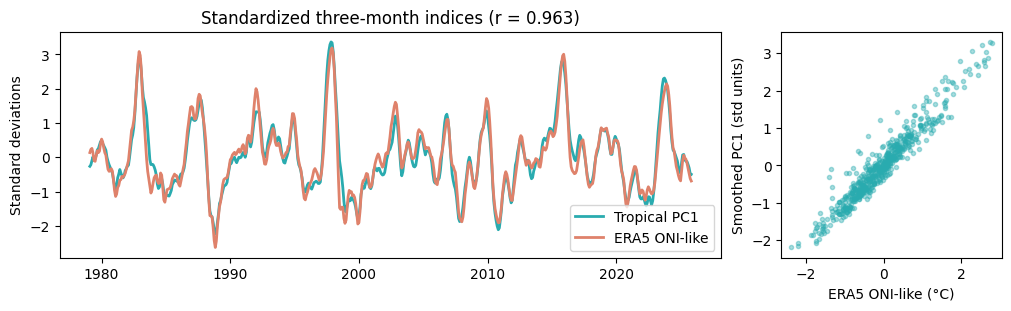

In [11]:
comparison = xr.Dataset({"enso_pc1": enso_pc1, "oni_like": oni_era5}).dropna("time")
standardized = (comparison - comparison.mean("time")) / comparison.std("time", ddof=1)
r = float(xr.corr(comparison.enso_pc1, comparison.oni_like, dim="time"))
fig, axes = plt.subplots(1, 2, figsize=(10, 3), layout="constrained", gridspec_kw={"width_ratios": [3, 1]})
for name, label, color in [
    ("enso_pc1", "Tropical PC1", "#29ABAF"),
    ("oni_like", "ERA5 ONI-like", "#DF826B"),
]:
    axes[0].plot(standardized.time, standardized[name], label=label, color=color, linewidth=2)
axes[0].legend()
axes[0].set(title=f"Standardized three-month indices (r = {r:.3f})", ylabel="Standard deviations")
axes[1].scatter(comparison.oni_like, comparison.enso_pc1, s=9, alpha=0.4, color="#29ABAF")
axes[1].set(xlabel="ERA5 ONI-like (°C)", ylabel="Smoothed PC1 (std units)")
print(f"Correlation on {comparison.sizes['time']} shared months: {r:.3f}")

## 6. Save the indices

Save monthly Niño 3.4 anomalies, the ONI-like series and tropical PC1 as NetCDF and CSV.

In [12]:
output_path = repo_root / "toolkit" / "datamining" / "outputs"
output_path.mkdir(exist_ok=True)
indices = xr.Dataset({
    "nino34_era5": nino34,
    "oni_like_era5": oni_era5,
    "enso_pc1_monthly": enso_pcs.isel(n_component=0, drop=True),
    "enso_pc1_3month": enso_pc1,
})
indices["enso_pc1_monthly"].attrs = {"units": "1", "long_name": "Standardized tropical Pacific PC1"}
indices.attrs = {
    "source": sst_file.name,
    "period": f"{start_year}–{end_year}",
    "grid": f"{resolution:g} degree spatial block means",
    "anomaly_baseline": "1991–2020",
    "pca_domain": "30S–30N, 120E–290E",
    "pca_preprocessing": "Monthly anomalies; local linear detrend; sqrt(cos(latitude)) weights; no feature standardization",
    "note": "ERA5 ONI-like index uses undetrended anomalies and a fixed baseline; not CPC ONI.",
}
stem = f"era5_pacific_sst_indices_{start_year}-{end_year}_{resolution:g}deg"
indices.to_netcdf(output_path / f"{stem}.nc")
indices.to_dataframe().to_csv(output_path / f"{stem}.csv")
print(f"Saved NetCDF and CSV in {output_path}")
indices

Saved NetCDF and CSV in /workspaces/BlueMath_Course_Corvallis/toolkit/datamining/outputs


<xarray.Dataset> Size: 23kB
Dimensions:           (time: 564)
Coordinates:
  * time              (time) datetime64[ns] 5kB 1979-01-01 ... 2025-12-01
Data variables:
    nino34_era5       (time) float64 5kB -0.009159 0.1193 ... -0.7288 -0.6649
    oni_like_era5     (time) float64 5kB nan 0.07653 0.1573 ... -0.6581 nan
    enso_pc1_monthly  (time) float64 5kB -0.04376 -0.3086 ... -0.6346 -0.4071
    enso_pc1_3month   (time) float64 5kB nan -0.2565 -0.2147 ... -0.4862 nan
Attributes:
    source:             era5_pacific_sst_1979-2025_2deg_blockmean_monthly_K.nc
    period:             1979–2025
    grid:               2 degree spatial block means
    anomaly_baseline:   1991–2020
    pca_domain:         30S–30N, 120E–290E
    pca_preprocessing:  Monthly anomalies; local linear detrend; sqrt(cos(lat...
    note:               ERA5 ONI-like index uses undetrended anomalies and a ...

## Takeaways

- Every PCA uses the same tropical Pacific domain.
- PCA extracts spatial patterns and their temporal scores from SST; the anomaly PCA removes local linear trends.
- The independent Niño 3.4 calculation averages undetrended anomalies within a small fixed box, then smooths over three months.
- The final comparison measures agreement between two different analyses; PC1 is not ONI.
- The ERA5 index uses a fixed 1991–2020 baseline and is not the published CPC ONI.
